# Scatter Plots: TE vs TR Scores across DDL Stages

Generates four individual scatter plots (one per DDL stage) plus one combined 2x2 overview figure.

**Requirements:** `DDL_TRAI_Scores.xlsx` must be in the **same folder** as this notebook.

Install packages if needed:
```
pip install pandas matplotlib openpyxl
```


──────────────────────────────────────────────────
Stage 1 – Discovery & Development
Saved → /Users/Flurina/Desktop/Scatterplots_BA/scatter_stage1.png


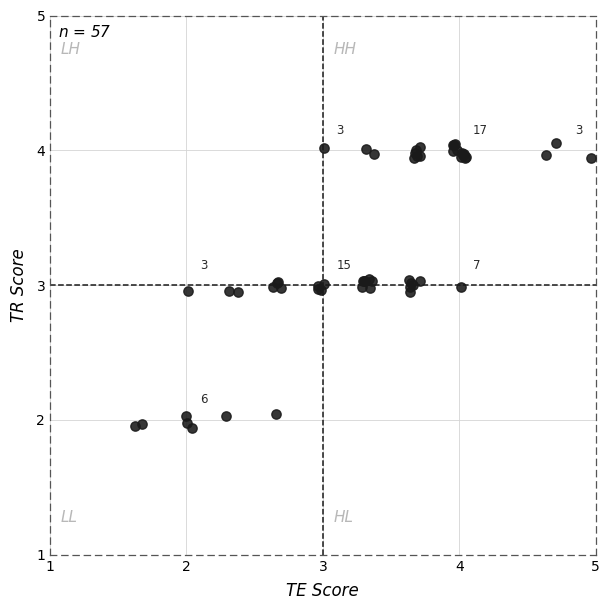


──────────────────────────────────────────────────
Stage 2 – Preclinical Research
Saved → /Users/Flurina/Desktop/Scatterplots_BA/scatter_stage2.png


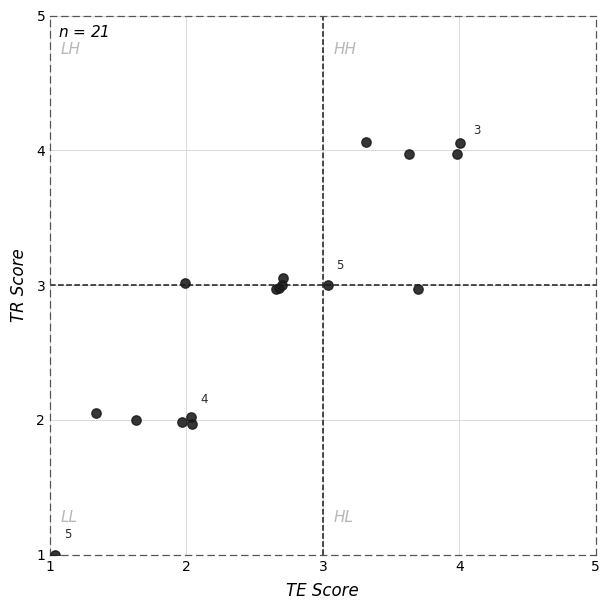


──────────────────────────────────────────────────
Stage 3 – Clinical Research
Saved → /Users/Flurina/Desktop/Scatterplots_BA/scatter_stage3.png


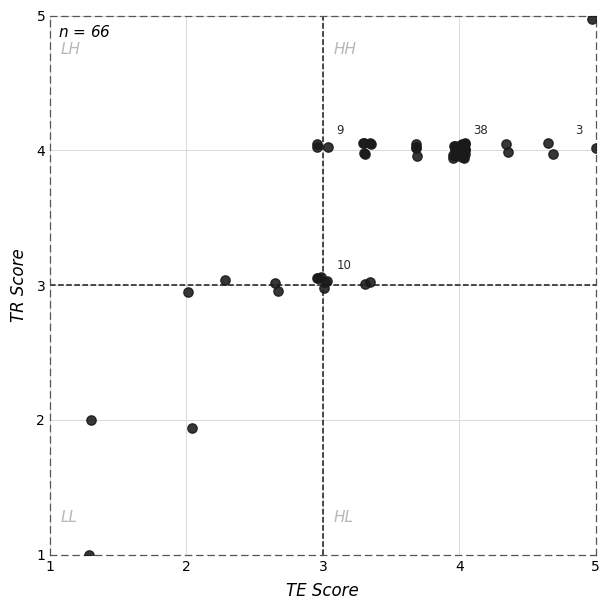


──────────────────────────────────────────────────
Stage 4 – Regulatory Review
Saved → /Users/Flurina/Desktop/Scatterplots_BA/scatter_stage4.png


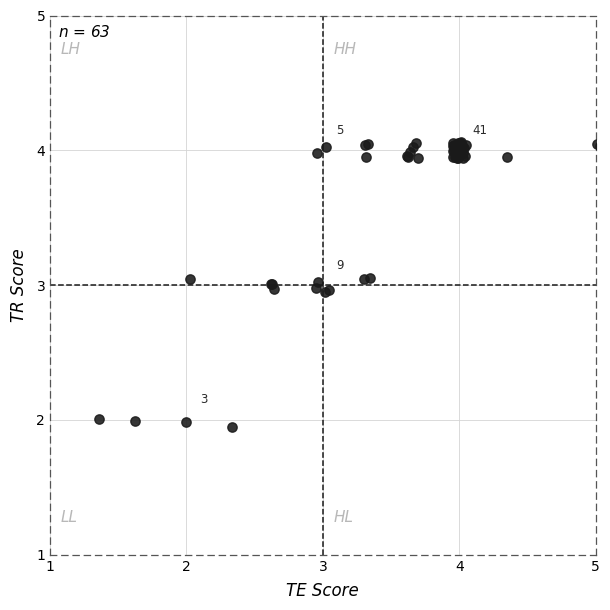


Combined figure saved → /Users/Flurina/Desktop/Scatterplots_BA/scatter_all_stages.png


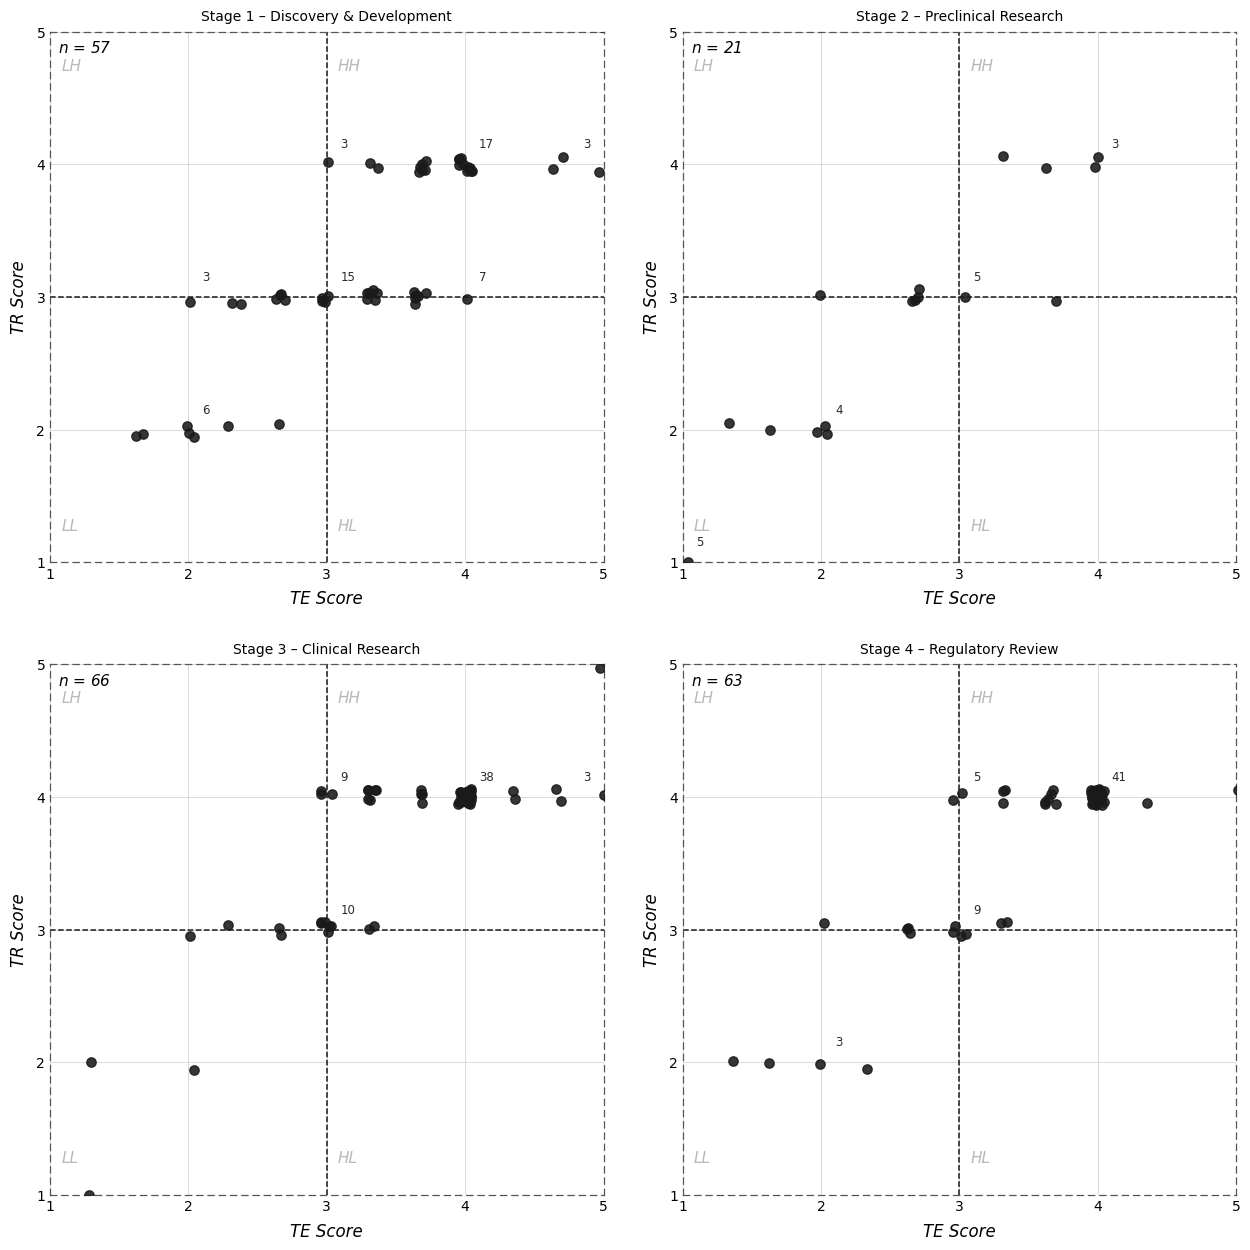

In [1]:
# =============================================================
# Scatter Plots: TE vs TR Scores across DDL Stages
# =============================================================
# Run this code in a Jupyter Notebook.
# Requirements: DDL_TRAI_Scores.xlsx must be in the SAME folder
# as this notebook. Works on any machine without path changes.
# =============================================================

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from collections import Counter

# ── Reproducible jitter ──────────────────────────────────────
np.random.seed(42)

# ── Load data (relative path → works on any machine) ─────────
notebook_dir = os.getcwd()   # Jupyter sets cwd to notebook folder
data_path = os.path.join(notebook_dir, "DDL_TRAI_Scores.xlsx")
df = pd.read_excel(data_path, sheet_name="Task_TRAI_Scores")

# ── Stage configuration ───────────────────────────────────────
stages = {
    1: "Stage 1 – Discovery & Development",
    2: "Stage 2 – Preclinical Research",
    3: "Stage 3 – Clinical Research",
    4: "Stage 4 – Regulatory Review",
}

# ── Design constants ──────────────────────────────────────────
FIGSIZE         = (6.2, 6.2)
POINT_COLOR     = "#1a1a1a"
POINT_SIZE      = 45
POINT_ALPHA     = 0.88
GRID_COLOR      = "#d4d4d4"
DIVIDER_COLOR   = "#1a1a1a"
QUADRANT_COLOR  = "#b8b8b8"
CLUSTER_COLOR   = "#2a2a2a"
JITTER_TE       = 0.05   # small jitter on TE (x)
JITTER_TR       = 0.06   # slightly more jitter on TR (y, integer values)
CLUSTER_MIN     = 3      # annotate clusters with >= this many points


def get_clusters(te_vals, tr_vals, min_count=3):
    """
    Group points by rounding TE to nearest integer, TR already integer.
    Returns dict {(te_center, tr_center): count} for clusters >= min_count.
    """
    te_rounded = np.round(te_vals).astype(int)
    tr_rounded = np.round(tr_vals).astype(int)
    counts = Counter(zip(te_rounded, tr_rounded))
    return {(float(k[0]), float(k[1])): v
            for k, v in counts.items() if v >= min_count}


def make_scatter(stage_num, ax=None):
    """Draw one scatter plot for a DDL stage onto `ax` (or create new figure)."""
    sub = df[df["dominant_stage"] == stage_num].copy()
    n   = len(sub)
    te  = sub["te_score"].values.astype(float)
    tr  = sub["trai_score"].values.astype(float)

    # ── Apply display jitter ──────────────────────────────────
    te_disp = te + np.random.uniform(-JITTER_TE, JITTER_TE, n)
    tr_disp = tr + np.random.uniform(-JITTER_TR, JITTER_TR, n)

    # ── Create axes if needed ─────────────────────────────────
    standalone = ax is None
    if standalone:
        fig, ax = plt.subplots(figsize=FIGSIZE)
        fig.patch.set_facecolor("white")

    ax.set_facecolor("white")

    # ── Grid lines (light grey at each integer) ───────────────
    ax.set_xticks([1, 2, 3, 4, 5])
    ax.set_yticks([1, 2, 3, 4, 5])
    ax.grid(True, which="major", color=GRID_COLOR, linewidth=0.6,
            linestyle="-", zorder=0)
    ax.set_axisbelow(True)

    # ── Quadrant dividers (dashed, at x=3 and y=3) ───────────
    ax.axvline(x=3, color=DIVIDER_COLOR, linestyle="--",
               linewidth=1.1, zorder=2)
    ax.axhline(y=3, color=DIVIDER_COLOR, linestyle="--",
               linewidth=1.1, zorder=2)

    # ── Scatter points ────────────────────────────────────────
    ax.scatter(te_disp, tr_disp,
               color=POINT_COLOR, s=POINT_SIZE,
               alpha=POINT_ALPHA, zorder=3)

    # ── Axis limits and ticks ─────────────────────────────────
    ax.set_xlim(1, 5)
    ax.set_ylim(1, 5)
    ax.tick_params(axis="both", which="major", labelsize=10,
                   length=0)   # hide tick marks, keep labels

    # ── Axis labels (italic) ──────────────────────────────────
    ax.set_xlabel("TE Score", style="italic", fontsize=12,
                  labelpad=6)
    ax.set_ylabel("TR Score", style="italic", fontsize=12,
                  labelpad=6, rotation=90)

    # ── Quadrant labels ───────────────────────────────────────
    kw = dict(color=QUADRANT_COLOR, style="italic", fontsize=11,
              transform=ax.transData, zorder=4)
    ax.text(1.08, 4.80, "LH", ha="left",  va="top",    **kw)
    ax.text(3.08, 4.80, "HH", ha="left",  va="top",    **kw)
    ax.text(1.08, 1.22, "LL", ha="left",  va="bottom", **kw)
    ax.text(3.08, 1.22, "HL", ha="left",  va="bottom", **kw)

    # ── n= annotation (top-left, outside plot area) ───────────
    ax.text(0.015, 0.985, f"$n$ = {n}",
            transform=ax.transAxes,
            fontsize=11, style="italic",
            va="top", ha="left", zorder=5)

    # ── Dashed plot border ────────────────────────────────────
    for spine in ax.spines.values():
        spine.set_linestyle((0, (5, 4)))  # dashed
        spine.set_linewidth(0.9)
        spine.set_color("#555555")

    # ── Cluster annotations ───────────────────────────────────
    clusters = get_clusters(te, tr, min_count=CLUSTER_MIN)
    for (te_c, tr_c), count in clusters.items():
        # Offset annotation slightly above-right of the cluster centre
        x_ann = te_c + 0.10
        y_ann = tr_c + 0.10
        # Keep annotation inside axes
        x_ann = min(x_ann, 4.85)
        y_ann = min(y_ann, 4.85)
        ax.annotate(
            str(count),
            xy=(te_c, tr_c),
            xytext=(x_ann, y_ann),
            fontsize=8.5,
            color=CLUSTER_COLOR,
            ha="left", va="bottom",
            zorder=6,
        )

    if standalone:
        plt.tight_layout()
        out_path = os.path.join(notebook_dir,
                                f"scatter_stage{stage_num}.png")
        plt.savefig(out_path, dpi=200, bbox_inches="tight",
                    facecolor="white")
        print(f"Saved → {out_path}")
        plt.show()

    return ax


# ═══════════════════════════════════════════════════════════════
# OPTION A — Four individual plots (one per cell / call)
# ═══════════════════════════════════════════════════════════════

for stage_num in [1, 2, 3, 4]:
    print(f"\n{'─'*50}")
    print(f"{stages[stage_num]}")
    make_scatter(stage_num)


# ═══════════════════════════════════════════════════════════════
# OPTION B — All four in a 2×2 grid (one combined figure)
# ═══════════════════════════════════════════════════════════════

fig, axes = plt.subplots(2, 2, figsize=(13, 13))
fig.patch.set_facecolor("white")
np.random.seed(42)   # reset seed so jitter matches Option A

for i, (stage_num, title) in enumerate(stages.items()):
    row, col = divmod(i, 2)
    ax = axes[row][col]
    make_scatter(stage_num, ax=ax)
    ax.set_title(title, fontsize=10, pad=8)

plt.tight_layout(pad=2.5)
combined_path = os.path.join(notebook_dir, "scatter_all_stages.png")
plt.savefig(combined_path, dpi=200, bbox_inches="tight",
            facecolor="white")
print(f"\nCombined figure saved → {combined_path}")
plt.show()
